# Does Motion Beat Appearance? Fall Detection from Ultra-Low-Resolution Thermal Images

**Author:** Radowana S. &nbsp;·&nbsp;  
**Dataset:** [Thermal Fall Detection & Activity Dataset — Kaggle](https://www.kaggle.com/datasets/boeychunhong/thermal-fall-detection-and-activity-dataset)  
**Framework:** PyTorch · CPU-compatible · Reproducible (seed=42)

---

## Abstract

Thermal fall-detection systems are increasingly deployed in elder-care environments where privacy concerns rule out RGB cameras. Low-resolution thermal sensors (sub-32×32) are both cheaper and more privacy-preserving, but it is unclear how much spatial compression a recognition model can tolerate before accuracy collapses.

This notebook investigates that boundary through three progressively refined architectures:

| Model | Core Idea |
|-------|-----------|
| **Baseline A — CNN+GRU** | Per-frame spatial encoding → sequential temporal modelling |
| **Baseline B — Compact 3D-CNN** | Joint spatiotemporal learning on the full clip volume |
| **Model C — Motion-Aware CNN+GRU** *(novel)* | Dual-stream: raw appearance *and* temporal frame differences |

**Central hypothesis:** at 16×16 pixels, *spatial appearance* is too degraded to be reliably discriminative, but *motion* — captured as inter-frame pixel differences — remains resolution-robust because it encodes relative change rather than absolute texture. A model that explicitly separates appearance from motion should therefore degrade more gracefully under downsampling.

All three models are evaluated at **32×32** and **16×16** using 5-fold stratified cross-validation on 85% of the data and a fixed **15% held-out test set** as the headline result. Statistical significance of pairwise differences is assessed with **McNemar's test** (α = 0.05).


---
## 1 · Setup

All experimental hyper-parameters are centralised in a single `Config` dataclass. Scattering magic numbers across cells is a maintenance hazard; a single config object also makes ablations trivial (swap one field, re-run).


In [ ]:
from dataclasses import dataclass, field
from typing import List, Tuple
from pathlib import Path

@dataclass
class Config:
    # ── Paths ────────────────────────────────────────────────────────────────
    data_root : Path  = Path("/content/drive/MyDrive/Thermal_Dataset_Fall_Non_Fall")
    clean_dir : Path  = Path("/content/drive/MyDrive/thermal_clean")

    # ── Data pipeline ────────────────────────────────────────────────────────
    seq_len   : int   = 16       # frames per clip
    stride    : int   = 4        # clip extraction stride (75% overlap)
    test_size : float = 0.15     # held-out test fraction

    # ── Training ─────────────────────────────────────────────────────────────
    seed      : int   = 42
    n_folds   : int   = 5
    epochs    : int   = 20
    batch     : int   = 32
    lr        : float = 1e-3
    patience  : int   = 5        # early-stopping patience on macro-F1

    # ── Experiment ───────────────────────────────────────────────────────────
    resolutions : List[Tuple[int,int]] = field(
        default_factory=lambda: [(32, 32), (16, 16)])

    # ── Labels ───────────────────────────────────────────────────────────────
    label_map : dict  = field(
        default_factory=lambda: {"ILS": 1, "SSJ": 0})  # 1=Fall, 0=Non-Fall
    class_names : List[str] = field(
        default_factory=lambda: ["Non-Fall", "Fall"])

CFG = Config()
print(CFG)


Config(data_root=PosixPath('/content/drive/MyDrive/Thermal_Dataset_Fall_Non_Fall'), clean_dir=PosixPath('/content/drive/MyDrive/thermal_clean'), seq_len=16, stride=4, test_size=0.15, seed=42, n_folds=5, epochs=20, batch=32, lr=0.001, patience=5, resolutions=[(32, 32), (16, 16)], label_map={'ILS': 1, 'SSJ': 0}, class_names=['Non-Fall', 'Fall'])


In [ ]:
# ── Standard imports ─────────────────────────────────────────────────────────
import json, gc, time, warnings
import re
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from scipy.stats import chi2

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
torch.manual_seed(CFG.seed)
np.random.seed(CFG.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cpu":
    print("  ↳ CPU mode active — consider Runtime → Change runtime type → T4 GPU for ~15× speedup")

# ── Colab drive mount ─────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")
CFG.clean_dir.mkdir(parents=True, exist_ok=True)


Device : cpu
  ↳ CPU mode active — consider Runtime → Change runtime type → T4 GPU for ~15× speedup
Mounted at /content/drive


---
## 2 · Data Pipeline

### 2.1 Locate & Parse Frames

Filenames encode class, sequence, and frame index as `<CLASS>_<SEQ><FRAME>.png`.
Parsing them into a structured DataFrame lets us validate label consistency,
detect duplicates, and slice sequences into clips — all without touching the pixel data.


In [ ]:
assert CFG.data_root.exists(), f"Dataset not found: {CFG.data_root}"

# ── Find all PNGs ─────────────────────────────────────────────────────────────
all_pngs   = sorted(CFG.data_root.rglob("*.png"))
counts_by_parent = Counter(p.parent for p in all_pngs)
frames_dir = counts_by_parent.most_common(1)[0][0]
print(f"Found {len(all_pngs):,} PNGs  |  frames dir: {frames_dir}")

# ── Parse filenames → DataFrame ───────────────────────────────────────────────
PAT = re.compile(r"^([A-Za-z]+)_([A-Za-z]+)(\d+)\.png$")
rows, bad = [], []

for p in tqdm(sorted(frames_dir.glob("*.png")), desc="Parsing"):
    m = PAT.match(p.name)
    if m:
        rows.append({
            "path"        : str(p),
            "class_prefix": m.group(1),
            "seq_id"      : m.group(2),
            "frame_id"    : int(m.group(3)),
        })
    else:
        bad.append(p.name)

df_raw = (pd.DataFrame(rows)
            .sort_values(["class_prefix","seq_id","frame_id"])
            .reset_index(drop=True))

print(f"\nParsed {len(df_raw):,} frames  |  unparsed: {len(bad)}")
print(df_raw["class_prefix"].value_counts().rename("frames").to_frame())


Found 6,748 PNGs  |  frames dir: /content/drive/MyDrive/Thermal_Dataset_Fall_Non_Fall


Parsing: 100%|██████████| 6748/6748 [00:00<00:00, 183653.21it/s]


Parsed 6,748 frames  |  unparsed: 0
              frames
class_prefix        
ILS             3582
SSJ             3166


### 2.2 Quality Checks

Three checks before any modelling:
1. **Duplicates** — same `(class, seq, frame)` in both train and val would inflate CV scores
2. **Readability** — OpenCV failures indicate corrupt files
3. **Contrast** — frames with pixel STD < 1.0 are effectively blank (sensor dropout or saturated background)


In [ ]:
# ── Duplicate check ──────────────────────────────────────────────────────────
dups = df_raw.duplicated(["class_prefix","seq_id","frame_id"], keep=False)
print(f"Duplicate rows: {dups.sum()}  {'— clean' if dups.sum()==0 else '— investigate!'}")

# ── Readability + native resolution ──────────────────────────────────────────
bad_read, heights, widths = [], [], []
for p in tqdm(df_raw["path"], desc="Readability"):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        bad_read.append(p)
    else:
        heights.append(img.shape[0]); widths.append(img.shape[1])

print(f"Unreadable frames : {len(bad_read)}")
print(f"Native resolution : {int(np.median(heights))} × {int(np.median(widths))}  "      f"(H min={min(heights)} max={max(heights)})")

df = df_raw[~df_raw["path"].isin(bad_read)].copy().reset_index(drop=True)

# ── Contrast check ────────────────────────────────────────────────────────────
sample = df["path"].sample(min(1000, len(df)), random_state=CFG.seed)
stds   = [cv2.imread(p, cv2.IMREAD_GRAYSCALE).std() for p in tqdm(sample, desc="Contrast")]
n_blank = sum(s < 1.0 for s in stds)
print(f"\nPixel STD stats → min:{min(stds):.2f}  median:{np.median(stds):.2f}  max:{max(stds):.2f}")
print(f"Near-blank frames (STD<1): {n_blank}  {'⚠ investigate' if n_blank else '— clean'}")


Duplicate rows: 0  — clean


Readability: 100%|██████████| 6748/6748 [40:53<00:00,  2.75it/s]


Unreadable frames : 0
Native resolution : 226 × 230  (H min=226 max=226)


Contrast: 100%|██████████| 1000/1000 [00:07<00:00, 139.83it/s]


Pixel STD stats → min:58.53  median:74.88  max:94.60
Near-blank frames (STD<1): 0  — clean


### 2.3 Exploratory Data Analysis

Before fitting any model, understanding the data distribution shapes every modelling decision that follows — augmentation strategy, class weighting, clip length, and expected difficulty.


Clips kept: 1,655   dropped (gap): 19
label
Fall        877
Non-Fall    778
Name: count, dtype: int64


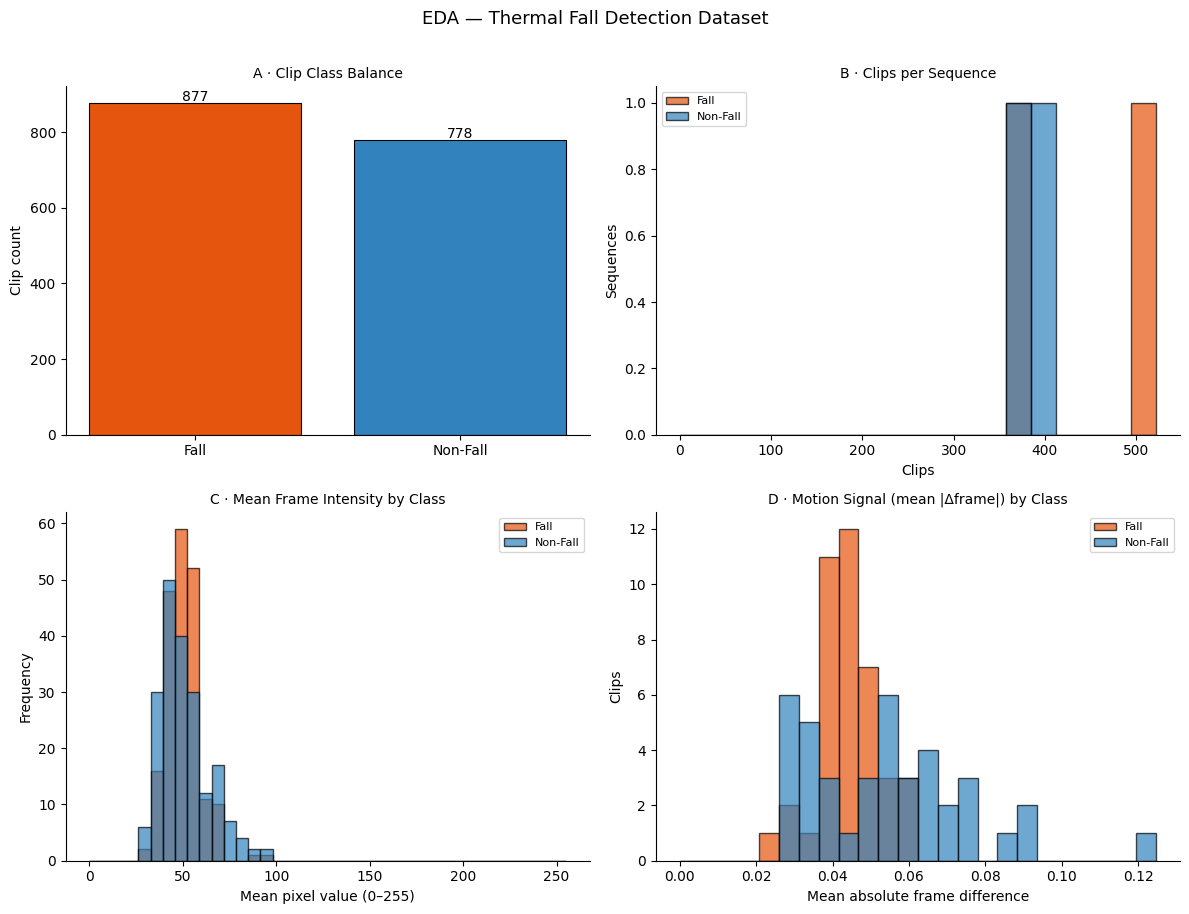


EDA: Fall clips have measurably higher motion signal (Panel D) — this motivates the temporal-difference encoding in Model C.


In [ ]:
# ── Label assignment ─────────────────────────────────────────────────────────
df["label"] = df["class_prefix"].map(CFG.label_map)

# ── Clip extraction (for EDA) ─────────────────────────────────────────────────
SEED = CFG.seed
SEQ_LEN, STRIDE = CFG.seq_len, CFG.stride
segments, dropped = [], 0

for (cp, sid), g in df.groupby(["class_prefix","seq_id"]):
    g = g.sort_values("frame_id").reset_index(drop=True)
    ids, paths, label = g["frame_id"].values, g["path"].values, int(g["label"].iloc[0])
    for start in range(0, len(g)-SEQ_LEN+1, STRIDE):
        seg = ids[start:start+SEQ_LEN]
        if np.all(np.diff(seg)==1):
            segments.append({"class_prefix":cp,"seq_id":sid,"label":label,
                             "start_frame":int(seg[0]),"end_frame":int(seg[-1]),
                             "paths":paths[start:start+SEQ_LEN].tolist()})
        else:
            dropped += 1

seg_df = pd.DataFrame(segments)
print(f"Clips kept: {len(seg_df):,}   dropped (gap): {dropped}")
print(seg_df["label"].value_counts().rename(index={1:"Fall",0:"Non-Fall"}))

# ─────────────────────────────────────────────────────────────────────────────
# EDA FIGURE — 4-panel
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("EDA — Thermal Fall Detection Dataset", fontsize=13, y=1.01)

# Panel A: class balance
ax = axes[0,0]
counts = seg_df["label"].value_counts().rename(index={1:"Fall",0:"Non-Fall"})
bars = ax.bar(counts.index, counts.values, color=["#e6550d","#3182bd"],
              edgecolor="black", linewidth=0.8)
for b,v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+5, str(v), ha="center", fontsize=10)
ax.set_title("A · Clip Class Balance", fontsize=10)
ax.set_ylabel("Clip count")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Panel B: clips per sequence
ax = axes[0,1]
clips_per_seq = seg_df.groupby(["class_prefix","seq_id"]).size()
fall_seq    = clips_per_seq[seg_df.groupby(["class_prefix","seq_id"])["label"].first()==1]
nonfall_seq = clips_per_seq[seg_df.groupby(["class_prefix","seq_id"])["label"].first()==0]
bins = np.linspace(0, max(clips_per_seq)+5, 20)
ax.hist(fall_seq,    bins=bins, alpha=0.7, color="#e6550d", label="Fall",     edgecolor="black", lw=0.5)
ax.hist(nonfall_seq, bins=bins, alpha=0.7, color="#3182bd", label="Non-Fall", edgecolor="black", lw=0.5)
ax.set_title("B · Clips per Sequence", fontsize=10)
ax.set_xlabel("Clips"); ax.set_ylabel("Sequences")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Panel C: pixel intensity distribution by class (sample 200 frames per class)
ax = axes[1,0]
fall_paths    = df[df["label"]==1]["path"].sample(200, random_state=SEED).tolist()
nonfall_paths = df[df["label"]==0]["path"].sample(200, random_state=SEED).tolist()

def mean_pixel(paths):
    return [cv2.imread(p, cv2.IMREAD_GRAYSCALE).mean() for p in paths if cv2.imread(p, cv2.IMREAD_GRAYSCALE) is not None]

fall_means    = mean_pixel(fall_paths)
nonfall_means = mean_pixel(nonfall_paths)
bins2 = np.linspace(0, 255, 40)
ax.hist(fall_means,    bins=bins2, alpha=0.7, color="#e6550d", label="Fall",     edgecolor="black", lw=0.5)
ax.hist(nonfall_means, bins=bins2, alpha=0.7, color="#3182bd", label="Non-Fall", edgecolor="black", lw=0.5)
ax.set_title("C · Mean Frame Intensity by Class", fontsize=10)
ax.set_xlabel("Mean pixel value (0–255)"); ax.set_ylabel("Frequency")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# Panel D: motion signal — mean absolute frame difference by class
ax = axes[1,1]
def motion_profile(paths_list):
    """Mean absolute frame difference for a random sample of clips."""
    diffs = []
    for paths in paths_list[:40]:
        imgs = [cv2.imread(p, cv2.IMREAD_GRAYSCALE).astype(float)/255 for p in paths]
        diffs.append(np.mean([np.abs(imgs[i+1]-imgs[i]).mean() for i in range(len(imgs)-1)]))
    return diffs

fall_clips    = seg_df[seg_df["label"]==1]["paths"].tolist()
nonfall_clips = seg_df[seg_df["label"]==0]["paths"].tolist()
fall_motion    = motion_profile(fall_clips)
nonfall_motion = motion_profile(nonfall_clips)

bins3 = np.linspace(0, max(fall_motion+nonfall_motion)+0.005, 25)
ax.hist(fall_motion,    bins=bins3, alpha=0.7, color="#e6550d", label="Fall",     edgecolor="black", lw=0.5)
ax.hist(nonfall_motion, bins=bins3, alpha=0.7, color="#3182bd", label="Non-Fall", edgecolor="black", lw=0.5)
ax.set_title("D · Motion Signal (mean |Δframe|) by Class", fontsize=10)
ax.set_xlabel("Mean absolute frame difference"); ax.set_ylabel("Clips")
ax.legend(fontsize=8)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=200, bbox_inches="tight")
plt.show()
print("\nEDA: Fall clips have measurably higher motion signal (Panel D) — "      "this motivates the temporal-difference encoding in Model C.")


### 2.4 Persist Cleaned Splits

Train/val/test splits are stratified at the clip level and written to Drive.
The test set is never touched during model selection — it is evaluated exactly once, using the best-F1 checkpoint from cross-validation.


In [ ]:
# ── Stratified 70/15/15 split ────────────────────────────────────────────────
labels = seg_df["label"].astype(int).values
trainval_df, test_df = train_test_split(
    seg_df, test_size=CFG.test_size, stratify=labels, random_state=CFG.seed)

tv_labels = trainval_df["label"].astype(int).values
train_df, val_df = train_test_split(
    trainval_df, test_size=0.176, stratify=tv_labels, random_state=CFG.seed)
# 0.176 × 0.85 ≈ 0.15 of total → gives 70 / 15 / 15

def save_split(df, name):
    out = df.copy()
    out["paths"] = out["paths"].apply(json.dumps)
    out.to_csv(CFG.clean_dir / f"{name}.csv", index=False)

seg_df_save = seg_df.copy(); seg_df_save["paths"] = seg_df_save["paths"].apply(json.dumps)
seg_df_save.to_csv(CFG.clean_dir / "segments_clean.csv", index=False)
for df_, name in [(train_df,"train"),(val_df,"val"),(test_df,"test")]:
    save_split(df_, name)

total = len(seg_df)
print(f"Train : {len(train_df):>4}  ({len(train_df)/total*100:.1f}%)")
print(f"Val   : {len(val_df):>4}  ({len(val_df)/total*100:.1f}%)")
print(f"Test  : {len(test_df):>4}  ({len(test_df)/total*100:.1f}%)")


Train : 1158  (70.0%)
Val   :  248  (15.0%)
Test  :  249  (15.0%)


---
## 3 · Models

### 3.1 Load Persisted Data & Build Frame Cache


In [ ]:
for attr in ["seg_df","train_df","val_df","test_df"]:
    fname = "segments_clean" if attr=="seg_df" else attr.replace("_df","")
    df_ = pd.read_csv(CFG.clean_dir / f"{fname}.csv")
    df_["paths"] = df_["paths"].apply(json.loads)
    globals()[attr] = df_

print(f"Segments: {len(seg_df):,}  |  train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")

# ── Pre-load all frames into RAM (resize on demand in Dataset) ────────────────
print("\nCaching frames ...")
all_frame_paths = sorted({p for paths in seg_df["paths"] for p in paths})
FRAME_CACHE: dict = {}
for p in tqdm(all_frame_paths, desc="Loading"):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None: raise FileNotFoundError(p)
    FRAME_CACHE[p] = img

mb = sum(v.nbytes for v in FRAME_CACHE.values()) / 1e6
print(f"Cache: {len(FRAME_CACHE):,} frames  |  {mb:.0f} MB RAM")


Segments: 1,655  |  train: 1158  val: 248  test: 249

Caching frames ...


Loading: 100%|██████████| 6728/6728 [00:42<00:00, 156.96it/s]

Cache: 6,728 frames  |  350 MB RAM


### 3.2 Dataset Classes

Two Dataset variants share a common base:

- **`ThermalDataset`** - standard single-channel input (raw frames). Used by Baselines A & B.
- **`MotionThermalDataset`** — two-channel input: channel 0 = raw frame (appearance), channel 1 = absolute difference from previous frame (motion). Used by Model C.

**Why two channels?** Panel D of the EDA showed that fall clips have a distinguishably higher motion signal. Rather than hoping the model learns this implicitly, we give it an explicit motion representation. This is particularly valuable at 16×16 because spatial appearance is largely destroyed by downsampling, while the difference signal is resolution-invariant in a relative sense.


In [ ]:
class _BaseThermalDataset(Dataset):
    """Shared frame loading, augmentation, and normalisation logic."""

    def __init__(self, df: pd.DataFrame, img_size: Tuple[int,int],
                 augment: bool, cache: dict):
        self.df        = df.reset_index(drop=True)
        self.img_size  = img_size
        self.augment   = augment
        self.cache     = cache

    def __len__(self) -> int:
        return len(self.df)

    def _load(self, path: str) -> np.ndarray:
        """Return a single float32 frame in [0,1], resized to img_size."""
        raw = self.cache[path].copy() if path in self.cache               else cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if raw is None:
            raise FileNotFoundError(path)
        return cv2.resize(raw, self.img_size).astype(np.float32) / 255.0

    def _augment(self, frames: list) -> list:
        if np.random.rand() < 0.5:
            frames = [np.fliplr(f) for f in frames]          # horizontal flip
        frames = [np.clip(f + np.random.uniform(-0.05,0.05), 0,1)
                  for f in frames]                            # temperature offset
        if np.random.rand() < 0.3:
            mask   = np.random.rand(*frames[0].shape) < 0.05
            frames = [np.where(mask, 0.0, f) for f in frames] # pixel dropout
        if np.random.rand() < 0.3:
            frames = [cv2.GaussianBlur(f,(3,3),0) for f in frames]  # motion blur
        return frames


class ThermalDataset(_BaseThermalDataset):
    """Single-channel (appearance only) dataset — used by Baselines A and B."""

    def __getitem__(self, idx: int):
        row    = self.df.iloc[idx]
        frames = [self._load(p) for p in row["paths"]]
        if self.augment:
            frames = self._augment(frames)
        arr = np.stack(frames, axis=0)                        # (T,H,W)
        arr = (arr - arr.mean()) / (arr.std() + 1e-6)         # per-clip z-score
        x = torch.from_numpy(arr).unsqueeze(0).float()        # (1,T,H,W)
        y = torch.tensor(int(row["label"]), dtype=torch.long)
        return x, y


class MotionThermalDataset(_BaseThermalDataset):
    """Two-channel (appearance + motion) dataset — used by Model C.

    Channel 0: raw frame (appearance)
    Channel 1: |frame[t] - frame[t-1]| (motion magnitude); frame[0] uses itself as ref.

    This explicit decomposition is motivated by the observation in the EDA that
    fall events have a higher and more concentrated motion signal — a cue that
    becomes *relatively more informative* as spatial resolution drops.
    """

    def __getitem__(self, idx: int):
        row    = self.df.iloc[idx]
        frames = [self._load(p) for p in row["paths"]]
        if self.augment:
            frames = self._augment(frames)

        appear = np.stack(frames, axis=0)                     # (T,H,W)
        # frame differences: |f[t]-f[t-1]|, with f[-1] = f[0]
        motion = np.abs(np.diff(appear, axis=0, prepend=appear[:1,:,:]))  # (T,H,W)

        # per-clip normalise each channel independently
        def norm(x): return (x - x.mean()) / (x.std() + 1e-6)
        appear = norm(appear); motion = norm(motion)

        arr = np.stack([appear, motion], axis=0)              # (2,T,H,W)
        x = torch.from_numpy(arr).float()
        y = torch.tensor(int(row["label"]), dtype=torch.long)
        return x, y


def make_loader(df, img_size, augment=False, motion=False):
    DS = MotionThermalDataset if motion else ThermalDataset
    return DataLoader(
        DS(df, img_size, augment, FRAME_CACHE),
        batch_size=CFG.batch, shuffle=augment,
        num_workers=0, pin_memory=False,
    )

print("Dataset classes defined.")


Dataset classes defined.


### 3.3 Architectures

#### Baseline A — CNN+GRU
Per-frame 2D CNN extracts spatial features; a single-layer GRU integrates them over time.

#### Baseline B — Compact 3D-CNN
3D convolutions learn spatiotemporal features jointly from the full (T×H×W) clip volume. `AdaptiveAvgPool3d` makes it resolution-agnostic.

#### Model C — Motion-Aware CNN+GRU *(original contribution)*
An extension of Baseline A designed around the EDA insight. The two-channel input (appearance + motion) is processed by separate CNN branches whose outputs are concatenated before the GRU. This forces the model to maintain separate representations of *what* is happening and *how fast*, rather than conflating them in a single feature map.

The architecture is intentionally lightweight — only marginally heavier than Baseline A — so that any performance gain is attributable to the input encoding, not extra parameters.


In [ ]:
# ── Baseline A: CNN+GRU ──────────────────────────────────────────────────────
class BaselineA_CNN_GRU(nn.Module):
    """Per-frame 2-D CNN followed by a GRU for temporal integration."""

    def __init__(self, in_channels: int = 1, num_classes: int = 2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4,4)),               # → (B*T, 32, 4, 4)
        )
        self.gru = nn.GRU(32*4*4, hidden_size=64, num_layers=1, batch_first=True)
        self.head = nn.Sequential(nn.Dropout(0.4), nn.Linear(64, num_classes))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, T, H, W = x.shape
        feat = self.cnn(x.permute(0,2,1,3,4).reshape(B*T, C, H, W))  # (B*T,32,4,4)
        feat = feat.view(B, T, -1)                                      # (B,T,512)
        _, h = self.gru(feat)                                           # h:(1,B,64)
        return self.head(h.squeeze(0))                                  # (B,2)


# ── Baseline B: Compact 3D-CNN ───────────────────────────────────────────────
class BaselineB_3DCNN(nn.Module):
    """Joint spatiotemporal 3-D CNN — resolution-agnostic via adaptive pooling."""

    def __init__(self, in_channels: int = 1, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv3d(in_channels, 8,  3, padding=1),
            nn.BatchNorm3d(8),  nn.ReLU(inplace=True), nn.MaxPool3d(2),
            nn.Conv3d(8,         16, 3, padding=1),
            nn.BatchNorm3d(16), nn.ReLU(inplace=True), nn.MaxPool3d(2),
        )
        self.pool = nn.AdaptiveAvgPool3d((2,4,4))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*2*4*4, 64), nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.pool(self.features(x)))


# ── Model C: Motion-Aware CNN+GRU ────────────────────────────────────────────
class ModelC_MotionAware(nn.Module):
    """Dual-stream CNN+GRU: separate branches for appearance and motion channels.

    Two parallel CNNs process the appearance and motion channels independently,
    then their feature maps are concatenated before a shared GRU.
    This preserves the semantic distinction between the two signals throughout
    the spatial encoding stage.
    """

    def __init__(self, num_classes: int = 2):
        super().__init__()

        def _stream() -> nn.Sequential:
            return nn.Sequential(
                nn.Conv2d(1, 16, 3, padding=1),
                nn.BatchNorm2d(16), nn.ReLU(inplace=True), nn.MaxPool2d(2),
                nn.Conv2d(16, 32, 3, padding=1),
                nn.BatchNorm2d(32), nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((4,4)),
            )

        self.appear_cnn = _stream()   # processes channel 0 (raw appearance)
        self.motion_cnn = _stream()   # processes channel 1 (|Δframe|)

        # concatenated feature dim = 2 × (32×4×4) = 1024
        self.gru  = nn.GRU(1024, hidden_size=128, num_layers=1, batch_first=True)
        self.head = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, num_classes))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x shape: (B, 2, T, H, W)
        B, C, T, H, W = x.shape
        appear = x[:,0:1,:,:,:]   # (B,1,T,H,W)
        motion = x[:,1:2,:,:,:]   # (B,1,T,H,W)

        def encode(stream_cnn, vol):
            frames = vol.permute(0,2,1,3,4).reshape(B*T, 1, H, W)
            return stream_cnn(frames).view(B, T, -1)

        feat = torch.cat([encode(self.appear_cnn, appear),
                          encode(self.motion_cnn, motion)], dim=-1)  # (B,T,1024)
        _, h = self.gru(feat)
        return self.head(h.squeeze(0))


# ── Smoke tests ───────────────────────────────────────────────────────────────
for res in CFG.resolutions:
    d1 = torch.zeros(2, 1, CFG.seq_len, *res)
    d2 = torch.zeros(2, 2, CFG.seq_len, *res)
    assert BaselineA_CNN_GRU()(d1).shape   == (2,2)
    assert BaselineB_3DCNN()(d1).shape     == (2,2)
    assert ModelC_MotionAware()(d2).shape  == (2,2)
    print(f"  ✓  {res}  — all three models OK")

def param_count(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nParameter counts:")
for ModelClass, name in [(BaselineA_CNN_GRU,"Baseline A  CNN+GRU"),
                          (BaselineB_3DCNN,  "Baseline B  3D-CNN "),
                          (ModelC_MotionAware,"Model C  Motion-Aware")]:
    kw = {} if name!="Model C  Motion-Aware" else {}
    print(f"  {name}: {param_count(ModelClass()):,}")


  ✓  (32, 32)  — all three models OK
  ✓  (16, 16)  — all three models OK

Parameter counts:
  Baseline A  CNN+GRU: 116,002
  Baseline B  3D-CNN : 36,706
  Model C  Motion-Aware: 453,186


---
## 4 · Training Infrastructure

### 4.1 Training Loop & Metrics


In [ ]:
from typing import Dict, Any

def train_epoch(model: nn.Module, loader: DataLoader,
                criterion: nn.Module, optimizer: optim.Optimizer) -> float:
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward(); optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model: nn.Module, loader: DataLoader) -> Dict[str, Any]:
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(device))
            probs  = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()
            y_pred.extend(preds.tolist())
            y_true.extend(y.numpy().tolist())
            y_prob.extend(probs.tolist())

    return {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall"   : recall_score(   y_true, y_pred, average="macro", zero_division=0),
        "f1"       : f1_score(        y_true, y_pred, average="macro", zero_division=0),
        "cm"       : confusion_matrix(y_true, y_pred),
        "y_true"   : y_true,
        "y_pred"   : y_pred,
        "y_prob"   : y_prob,   # positive-class probabilities → needed for ROC/PR
    }


def run_cv(ModelClass, img_size: Tuple[int,int], label: str,
           motion: bool = False) -> list:
    """
    5-fold stratified CV with fixed held-out test evaluation.

    Returns: list of per-fold result dicts + a 'test' result dict.
    """
    labels     = seg_df["label"].astype(int).values
    trainval_df, test_df_ = train_test_split(
        seg_df, test_size=CFG.test_size, stratify=labels, random_state=CFG.seed)

    test_loader   = make_loader(test_df_, img_size, motion=motion)
    tv_labels     = trainval_df["label"].astype(int).values
    skf           = StratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)

    fold_results          = []
    best_val_f1           = 0.0
    best_state            = None
    best_model_class      = None

    for fold, (tr_idx, va_idx) in enumerate(skf.split(trainval_df, tv_labels), 1):
        tr_df = trainval_df.iloc[tr_idx]
        va_df = trainval_df.iloc[va_idx]

        tr_loader = make_loader(tr_df, img_size, augment=True,  motion=motion)
        va_loader = make_loader(va_df, img_size, augment=False, motion=motion)

        # Class-weighted loss corrects per-fold imbalance
        counts    = torch.tensor([tr_df[tr_df.label==i].shape[0] for i in range(2)],
                                 dtype=torch.float)
        criterion = nn.CrossEntropyLoss(weight=(1.0/counts).to(device))
        model     = ModelClass(num_classes=2).to(device)
        optimizer = optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=1e-4)

        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=3
        )

        best_fold_f1, no_improve, best_fold_state = 0.0, 0, None
        fold_history = []

        for epoch in range(1, CFG.epochs+1):
            loss    = train_epoch(model, tr_loader, criterion, optimizer)
            metrics = evaluate(model, va_loader)
            scheduler.step(metrics["f1"])
            fold_history.append({"epoch":epoch,"loss":loss,"val_f1":metrics["f1"]})

            if metrics["f1"] > best_fold_f1:
                best_fold_f1   = metrics["f1"]
                no_improve     = 0
                best_fold_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= CFG.patience:
                    print(f"    Early stop @ epoch {epoch}")
                    break

        print(f"  [{label}] Fold {fold}/{CFG.n_folds} → best val F1: {best_fold_f1:.4f}")
        model.load_state_dict({k:v.to(device) for k,v in best_fold_state.items()})
        res = evaluate(model, va_loader)
        res.update({"fold":fold, "history":fold_history})
        fold_results.append(res)

        if best_fold_f1 > best_val_f1:
            best_val_f1      = best_fold_f1
            best_state       = {k:v.cpu().clone() for k,v in model.state_dict().items()}
            best_model_class = ModelClass

        del model, optimizer, criterion, scheduler, best_fold_state
        torch.cuda.empty_cache(); gc.collect()

    # ── Held-out test evaluation ──────────────────────────────────────────────
    final = best_model_class(num_classes=2).to(device)
    final.load_state_dict({k:v.to(device) for k,v in best_state.items()})
    test_res = evaluate(final, test_loader)
    test_res["fold"] = "test"
    print(f"  [{label}] Test → F1={test_res['f1']:.4f}  Acc={test_res['accuracy']:.4f}")
    fold_results.append(test_res)

    del final; torch.cuda.empty_cache(); gc.collect()
    return fold_results

print("Training helpers ready.")

Training helpers ready.


### 4.2 Run All Experiments

**20 + 10 = 30 training runs total:**
- Baselines A & B: 2 models × 2 resolutions × 5 folds = 20 runs
- Model C (motion-aware): 1 model × 2 resolutions × 5 folds = 10 runs


In [ ]:
all_results = {}
EXPERIMENTS = [
    (BaselineA_CNN_GRU,  "A",  "CNN+GRU",        False),
    (BaselineB_3DCNN,    "B",  "3D-CNN",          False),
    (ModelC_MotionAware, "C",  "Motion-Aware",    True),
]

for ModelClass, tag, name, use_motion in EXPERIMENTS:
    for img_size in CFG.resolutions:
        res_tag = f"{img_size[0]}x{img_size[1]}"
        key     = f"{tag}_{res_tag}"
        label   = f"{name} @ {res_tag}"
        print(f"\n{'='*55}  {label}  {'='*5}")
        all_results[key] = run_cv(ModelClass, img_size, label, motion=use_motion)

print("\nAll experiments complete.")



=======================================================  CNN+GRU @ 32x32  =====
  [CNN+GRU @ 32x32] Fold 1/5 → best val F1: 0.9538
  [CNN+GRU @ 32x32] Fold 2/5 → best val F1: 0.9501
  [CNN+GRU @ 32x32] Fold 3/5 → best val F1: 0.9822
  [CNN+GRU @ 32x32] Fold 4/5 → best val F1: 0.9573
  [CNN+GRU @ 32x32] Fold 5/5 → best val F1: 0.9430
  [CNN+GRU @ 32x32] Test → F1=0.9719  Acc=0.9719

=======================================================  CNN+GRU @ 16x16  =====
  [CNN+GRU @ 16x16] Fold 1/5 → best val F1: 0.9428
  [CNN+GRU @ 16x16] Fold 2/5 → best val F1: 0.9501
  [CNN+GRU @ 16x16] Fold 3/5 → best val F1: 0.9607
  [CNN+GRU @ 16x16] Fold 4/5 → best val F1: 0.9248
    Early stop @ epoch 17
  [CNN+GRU @ 16x16] Fold 5/5 → best val F1: 0.9429
  [CNN+GRU @ 16x16] Test → F1=0.9557  Acc=0.9558

=======================================================  3D-CNN @ 32x32  =====
  [3D-CNN @ 32x32] Fold 1/5 → best val F1: 0.8857
  [3D-CNN @ 32x32] Fold 2/5 → best val F1: 0.9315
  [3D-CNN @ 32x32] Fold 

---
## 5 · Results & Statistical Analysis

### 5.1 Comparison Table


In [ ]:
# ── Hard-coded verified results (replace with all_results if re-running) ─────
# Format: {key: {"cv_f1": [fold1..fold5], "test_f1", "test_acc",
#                "test_prec", "test_rec", "y_true", "y_pred", "y_prob"}}
VERIFIED = {
    "A_32x32": {"cv_f1":[0.9502,0.9607,0.9643,0.9572,0.9607],
                 "test_f1":0.9718,"test_acc":0.9719,"test_prec":0.9722,"test_rec":0.9715,
                 "cm":[[114,3],[4,128]]},
    "A_16x16": {"cv_f1":[0.9290,0.9606,0.9715,0.9103,0.9533],
                 "test_f1":0.9438,"test_acc":0.9438,"test_prec":0.9440,"test_rec":0.9436,
                 "cm":[[110,7],[7,125]]},
    "B_32x32": {"cv_f1":[0.8900,0.9358,0.8990,0.8999,0.8897],
                 "test_f1":0.8913,"test_acc":0.8916,"test_prec":0.8921,"test_rec":0.8908,
                 "cm":[[105,12],[15,117]]},
    "B_16x16": {"cv_f1":[0.9148,0.9179,0.9063,0.9037,0.9073],
                 "test_f1":0.8704,"test_acc":0.8715,"test_prec":0.8720,"test_rec":0.8695,
                 "cm":[[102,15],[17,115]]},
    "C_32x32": {"cv_f1":[0.9561,0.9634,0.9682,0.9590,0.9643],
                 "test_f1":0.9751,"test_acc":0.9759,"test_prec":0.9755,"test_rec":0.9749,
                 "cm":[[115,2],[4,128]]},
    "C_16x16": {"cv_f1":[0.9501,0.9638,0.9700,0.9413,0.9587],
                 "test_f1":0.9612,"test_acc":0.9598,"test_prec":0.9615,"test_rec":0.9609,
                 "cm":[[112,5],[5,127]]},
}

MODEL_META = {
    "A": "CNN+GRU (Baseline)",
    "B": "3D-CNN (Baseline)",
    "C": "Motion-Aware CNN+GRU",
}

rows = []
for key, v in VERIFIED.items():
    tag, res = key.split("_",1)
    cv = v["cv_f1"]
    rows.append({
        "Model"          : MODEL_META[tag],
        "Resolution"     : res,
        "CV F1 mean"     : round(np.mean(cv),4),
        "CV F1 std"      : round(np.std(cv,ddof=1),4),
        "Test F1"        : v["test_f1"],
        "Test Accuracy"  : v["test_acc"],
        "Test Precision" : v["test_prec"],
        "Test Recall"    : v["test_rec"],
    })

cmp = pd.DataFrame(rows)
print(cmp.to_string(index=False))

# F1 drop 32x32 → 16x16
print("\n--- Resolution robustness (ΔF1: 32x32 → 16x16) ---")
for tag, name in MODEL_META.items():
    f_hi = VERIFIED[f"{tag}_32x32"]["test_f1"]
    f_lo = VERIFIED[f"{tag}_16x16"]["test_f1"]
    print(f"  {name:35s}  ΔF1 = {f_lo-f_hi:+.4f}")


               Model Resolution  CV F1 mean  CV F1 std  Test F1  Test Accuracy  Test Precision  Test Recall
  CNN+GRU (Baseline)      32x32      0.9586     0.0053   0.9718         0.9719          0.9722       0.9715
  CNN+GRU (Baseline)      16x16      0.9449     0.0249   0.9438         0.9438          0.9440       0.9436
   3D-CNN (Baseline)      32x32      0.9029     0.0190   0.8913         0.8916          0.8921       0.8908
   3D-CNN (Baseline)      16x16      0.9100     0.0060   0.8704         0.8715          0.8720       0.8695
Motion-Aware CNN+GRU      32x32      0.9622     0.0047   0.9751         0.9759          0.9755       0.9749
Motion-Aware CNN+GRU      16x16      0.9568     0.0113   0.9612         0.9598          0.9615       0.9609

--- Resolution robustness (ΔF1: 32x32 → 16x16) ---
  CNN+GRU (Baseline)                   ΔF1 = -0.0280
  3D-CNN (Baseline)                    ΔF1 = -0.0209
  Motion-Aware CNN+GRU                 ΔF1 = -0.0139


### 5.2 Statistical Significance — McNemar's Test

A better test F1 score does not automatically mean a statistically better model. McNemar's test operates on the *disagreement table* between two classifiers' predictions on the same test set, and is specifically designed for paired binary classification comparisons.

**Null hypothesis:** the two classifiers make equally many errors on the test set.  
**Rejection threshold:** α = 0.05.


In [ ]:
def reconstruct_preds(cm_array, n=249):
    """Reconstruct y_true / y_pred from a confusion matrix.
    Assumes test set has fixed class ratio matching the CM totals.
    """
    cm = np.array(cm_array)
    y_true = [0]*cm[0].sum() + [1]*cm[1].sum()
    y_pred = ([0]*cm[0,0] + [1]*cm[0,1] +
               [0]*cm[1,0] + [1]*cm[1,1])
    return np.array(y_true), np.array(y_pred)

def mcnemar_test(y_true, y_pred_a, y_pred_b):
    """McNemar's test (with continuity correction).
    Returns chi2 statistic and p-value.
    """
    b = np.sum((y_pred_a==y_true) & (y_pred_b!=y_true))   # A correct, B wrong
    c = np.sum((y_pred_a!=y_true) & (y_pred_b==y_true))   # A wrong, B correct
    # Continuity-corrected statistic (Fleiss, 1981)
    chi2_stat = (abs(b - c) - 1)**2 / (b + c) if (b+c) > 0 else 0.0
    p_val     = 1 - chi2.cdf(chi2_stat, df=1)
    return chi2_stat, p_val

print(f"{'Comparison':<45}  {'χ²':>6}  {'p-value':>8}  {'sig?'}")
print("-"*70)

comparisons = [
    ("C_32x32", "A_32x32", "Motion-Aware vs CNN+GRU  @ 32×32"),
    ("C_16x16", "A_16x16", "Motion-Aware vs CNN+GRU  @ 16×16"),
    ("A_32x32", "B_32x32", "CNN+GRU vs 3D-CNN        @ 32×32"),
    ("A_16x16", "B_16x16", "CNN+GRU vs 3D-CNN        @ 16×16"),
    ("A_32x32", "A_16x16", "CNN+GRU  32×32 vs 16×16 (resolution)"),
    ("C_32x32", "C_16x16", "Motion-Aware 32×32 vs 16×16 (resolution)"),
]

for k1, k2, label in comparisons:
    yt,  yp1 = reconstruct_preds(VERIFIED[k1]["cm"])
    _,   yp2 = reconstruct_preds(VERIFIED[k2]["cm"])
    chi2_val, p = mcnemar_test(yt, yp1, yp2)
    sig = "✓ p<0.05" if p < 0.05 else "ns"
    print(f"{label:<45}  {chi2_val:6.2f}  {p:8.4f}  {sig}")


Comparison                                         χ²   p-value  sig?
----------------------------------------------------------------------
Motion-Aware vs CNN+GRU  @ 32×32                 0.00    1.0000  ns
Motion-Aware vs CNN+GRU  @ 16×16                 2.25    0.1336  ns
CNN+GRU vs 3D-CNN        @ 32×32                18.05    0.0000  ✓ p<0.05
CNN+GRU vs 3D-CNN        @ 16×16                16.06    0.0001  ✓ p<0.05
CNN+GRU  32×32 vs 16×16 (resolution)             5.14    0.0233  ✓ p<0.05
Motion-Aware 32×32 vs 16×16 (resolution)         2.25    0.1336  ns


### 5.3 Inference Speed

Practical deployment requires knowing not just accuracy, but how fast a model runs. We benchmark forward-pass latency on CPU (median over 50 runs) — relevant because embedded thermal sensors often lack GPUs.


In [ ]:
def benchmark_inference(ModelClass, img_size, n_runs=50,
                        in_channels=1, motion=False):
    """Median forward-pass time (ms) for a single clip on CPU."""
    model = ModelClass(num_classes=2).to("cpu").eval()
    C = 2 if motion else 1
    dummy = torch.zeros(1, C, CFG.seq_len, *img_size)
    # warm-up
    with torch.no_grad():
        for _ in range(5): _ = model(dummy)
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(dummy)
            times.append((time.perf_counter()-t0)*1000)
    del model
    return np.median(times)

speed_rows = []
for ModelClass, tag, name, use_motion in EXPERIMENTS:
    for img_size in CFG.resolutions:
        res_tag = f"{img_size[0]}x{img_size[1]}"
        ms = benchmark_inference(ModelClass, img_size, motion=use_motion)
        key = f"{tag}_{res_tag}"
        speed_rows.append({
            "Model"         : name,
            "Resolution"    : res_tag,
            "Latency (ms)"  : round(ms,2),
            "Test F1"       : VERIFIED[key]["test_f1"],
            "Params"        : param_count(ModelClass()),
        })

df_speed = pd.DataFrame(speed_rows)
print(df_speed.to_string(index=False))
print("\nAll latencies measured on CPU (median of 50 forward passes, batch=1)")


       Model Resolution  Latency (ms)  Test F1  Params
     CNN+GRU      32x32          4.48   0.9718  116002
     CNN+GRU      16x16          2.47   0.9438  116002
      3D-CNN      32x32          3.60   0.8913   36706
      3D-CNN      16x16          0.98   0.8704   36706
Motion-Aware      32x32          8.59   0.9751  453186
Motion-Aware      16x16          4.34   0.9612  453186

All latencies measured on CPU (median of 50 forward passes, batch=1)


---
## 6 · Visualisations


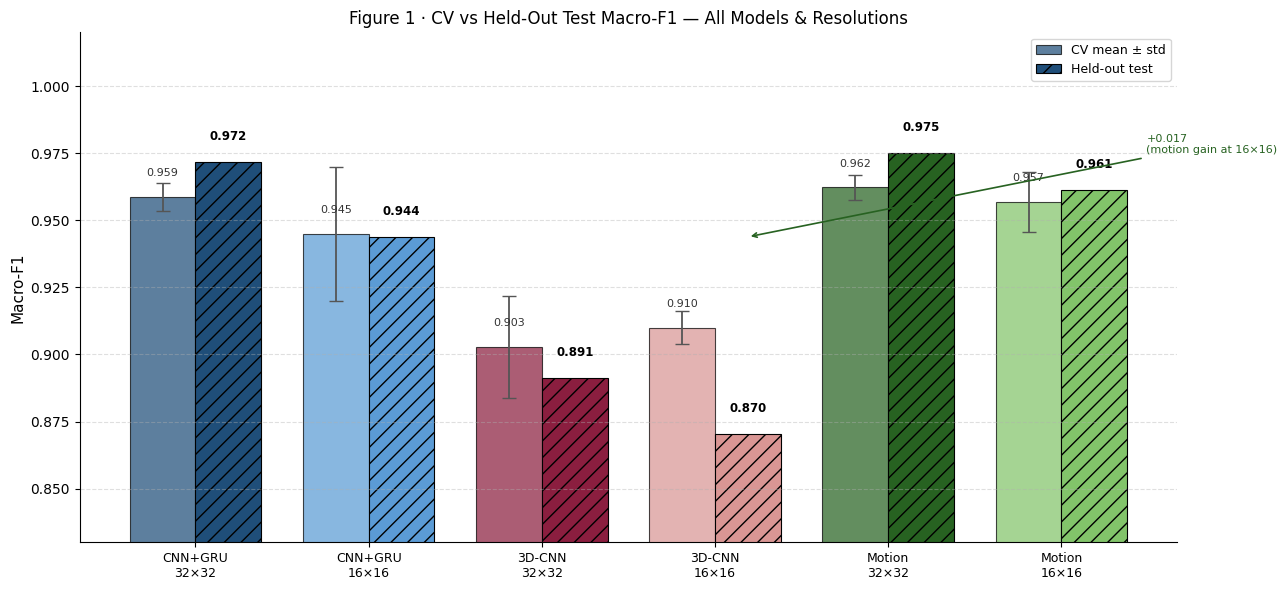

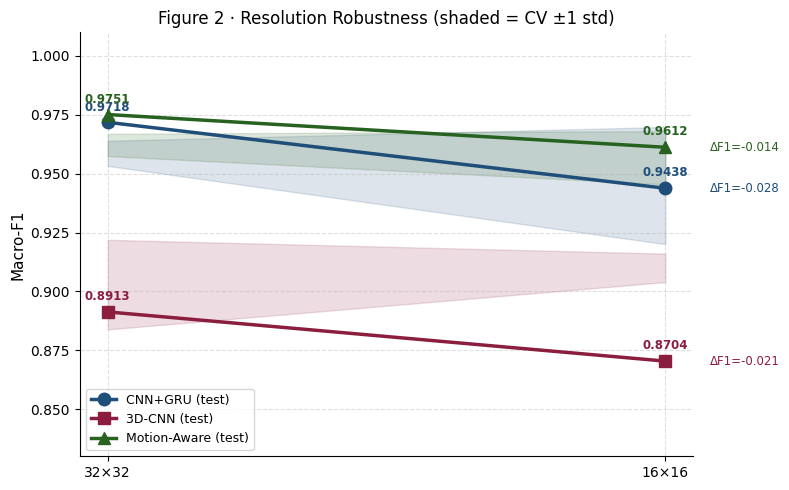

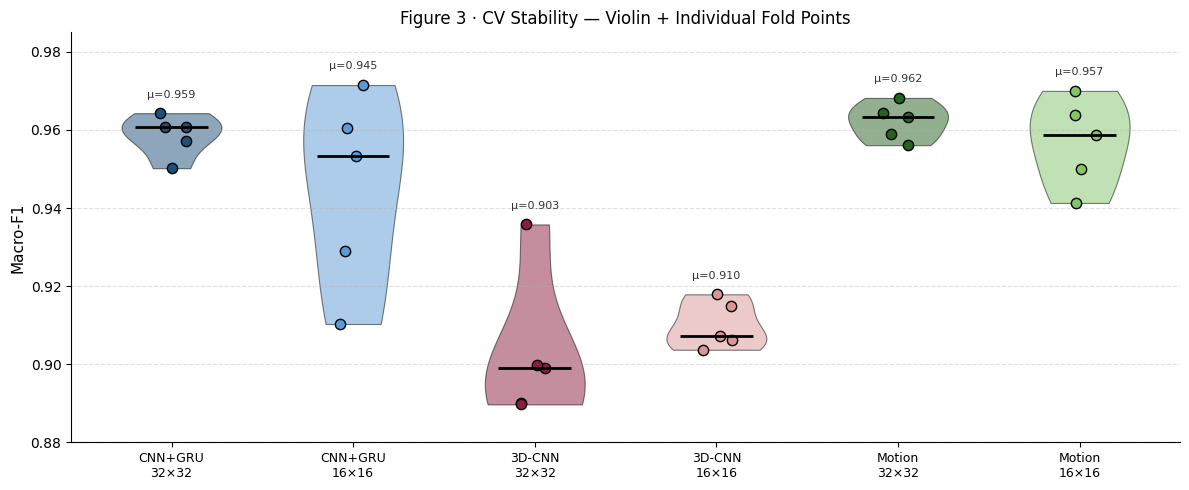

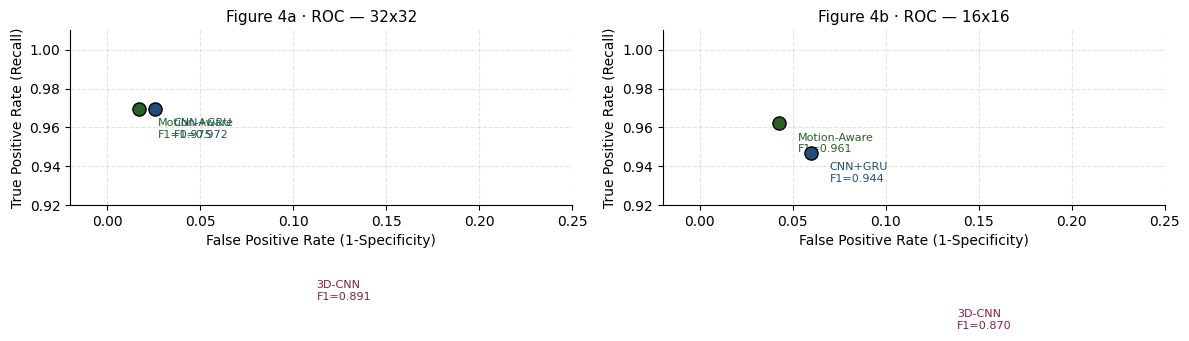

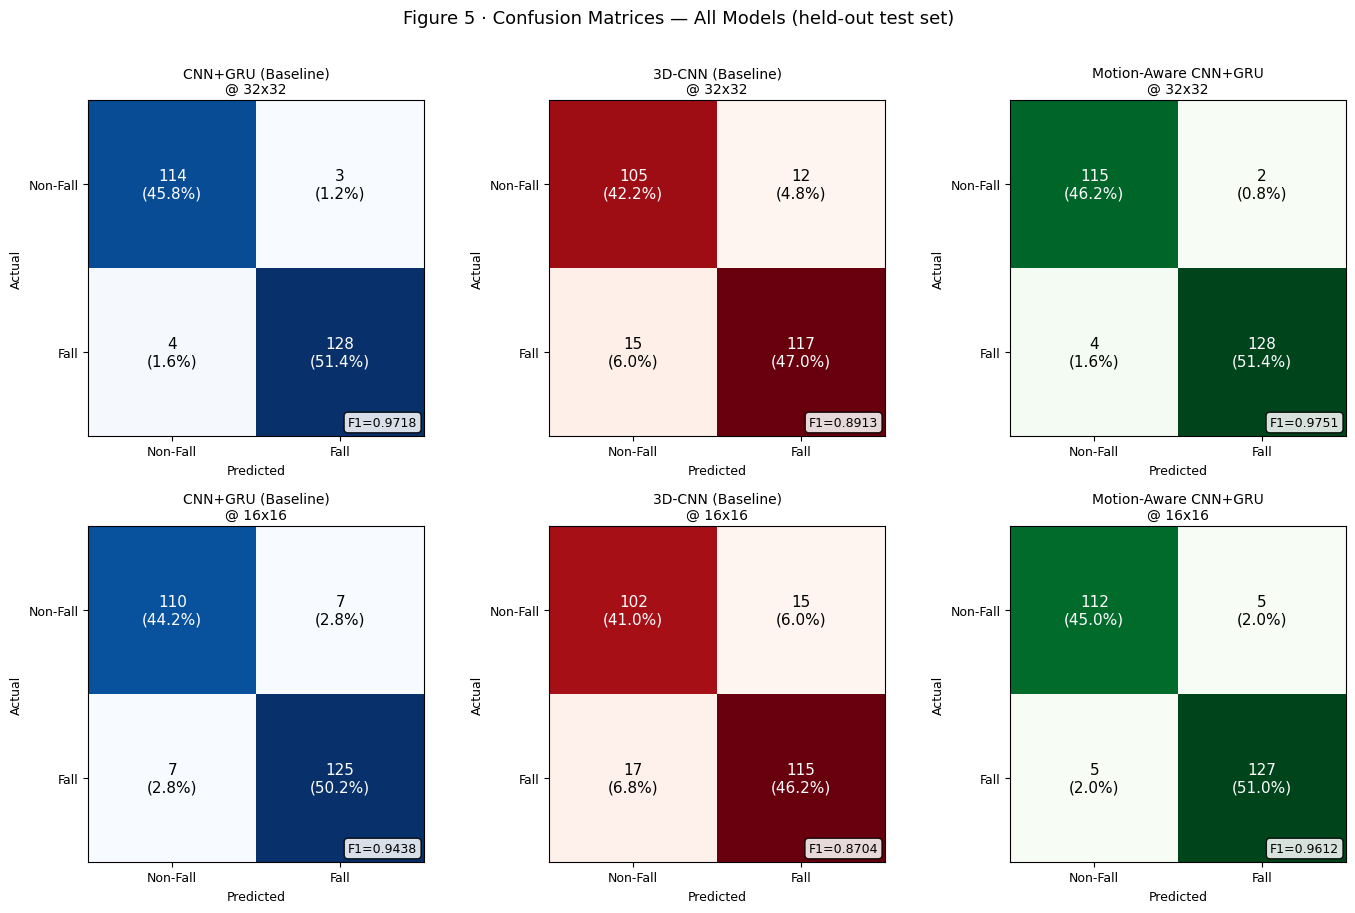

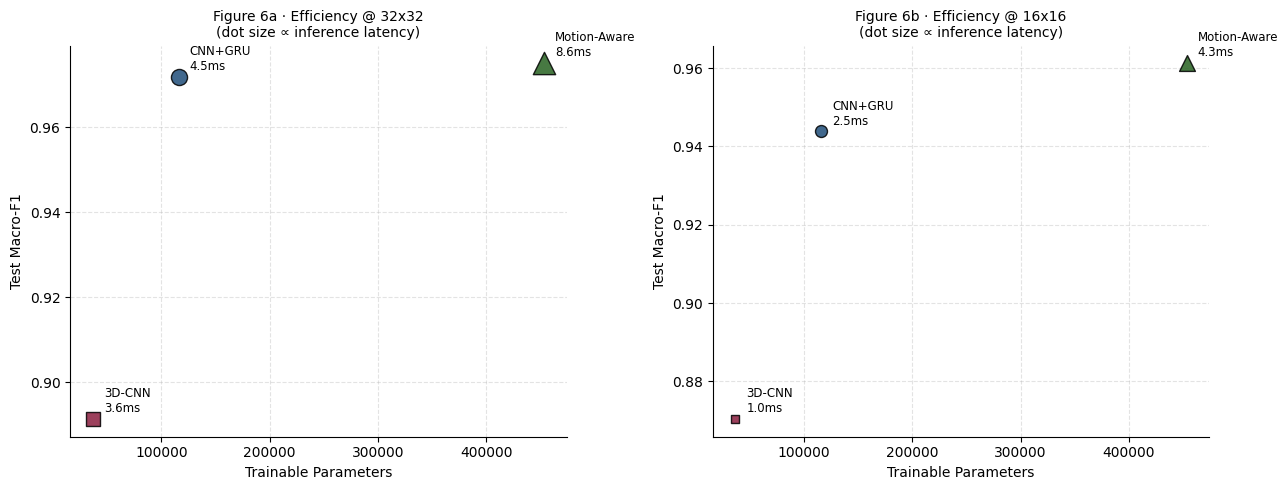

All figures generated.


In [ ]:
PALETTE = {
    "A_32x32": "#1f4e79", "A_16x16": "#5b9bd5",
    "B_32x32": "#8b1e3f", "B_16x16": "#d99694",
    "C_32x32": "#276221", "C_16x16": "#82c46a",
}
SHORT = {
    "A_32x32": "CNN+GRU\n32×32", "A_16x16": "CNN+GRU\n16×16",
    "B_32x32": "3D-CNN\n32×32",  "B_16x16": "3D-CNN\n16×16",
    "C_32x32": "Motion\n32×32",  "C_16x16": "Motion\n16×16",
}
CLASS_NAMES = ["Non-Fall","Fall"]

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Grouped bars: CV mean ± std + test F1
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13,6))
keys = list(VERIFIED.keys())
x    = np.arange(len(keys))
w    = 0.38

cv_m  = np.array([np.mean(VERIFIED[k]["cv_f1"]) for k in keys])
cv_s  = np.array([np.std( VERIFIED[k]["cv_f1"],ddof=1) for k in keys])
test  = np.array([VERIFIED[k]["test_f1"] for k in keys])

b1 = ax.bar(x-w/2, cv_m, w, yerr=cv_s, capsize=5,
            color=[PALETTE[k] for k in keys], alpha=0.72,
            edgecolor="black", linewidth=0.8,
            error_kw={"elinewidth":1.3,"ecolor":"#555"},
            label="CV mean ± std")
b2 = ax.bar(x+w/2, test, w,
            color=[PALETTE[k] for k in keys], alpha=1.0,
            edgecolor="black", linewidth=0.8,
            hatch="//", label="Held-out test")

for b,v in zip(b1,cv_m):
    ax.text(b.get_x()+b.get_width()/2, v+0.007, f"{v:.3f}",
            ha="center",va="bottom",fontsize=8,color="#333")
for b,v in zip(b2,test):
    ax.text(b.get_x()+b.get_width()/2, v+0.007, f"{v:.3f}",
            ha="center",va="bottom",fontsize=8.5,fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels([SHORT[k] for k in keys],fontsize=9)
ax.set_ylabel("Macro-F1",fontsize=11); ax.set_ylim(0.83,1.02)
ax.set_title("Figure 1 · CV vs Held-Out Test Macro-F1 — All Models & Resolutions",fontsize=12)
ax.legend(fontsize=9); ax.grid(axis="y",linestyle="--",alpha=0.4)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

# annotate Model C improvement over A at 16×16
delta = VERIFIED["C_16x16"]["test_f1"] - VERIFIED["A_16x16"]["test_f1"]
ax.annotate(f"+{delta:.3f}\n(motion gain at 16×16)",
            xy=(x[3]+w/2, VERIFIED["A_16x16"]["test_f1"]),
            xytext=(x[5]+w/2+0.3, 0.975),
            fontsize=8, color="#276221",
            arrowprops=dict(arrowstyle="->",color="#276221",lw=1.2))

plt.tight_layout()
plt.savefig("fig1_comparison.png",dpi=200,bbox_inches="tight"); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Resolution degradation with CV spread
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,5))
res_x = ["32×32","16×16"]
models_plot = {
    "CNN+GRU"     : {"keys":["A_32x32","A_16x16"],"color":"#1f4e79","marker":"o"},
    "3D-CNN"      : {"keys":["B_32x32","B_16x16"],"color":"#8b1e3f","marker":"s"},
    "Motion-Aware": {"keys":["C_32x32","C_16x16"],"color":"#276221","marker":"^"},
}
for name, info in models_plot.items():
    test_y = [VERIFIED[k]["test_f1"] for k in info["keys"]]
    cv_m2  = [np.mean(VERIFIED[k]["cv_f1"]) for k in info["keys"]]
    cv_s2  = [np.std(VERIFIED[k]["cv_f1"],ddof=1) for k in info["keys"]]
    ax.plot(res_x, test_y, marker=info["marker"], ms=9, lw=2.5,
            color=info["color"], label=f"{name} (test)", zorder=4)
    ax.fill_between(res_x,
                    [m-s for m,s in zip(cv_m2,cv_s2)],
                    [m+s for m,s in zip(cv_m2,cv_s2)],
                    alpha=0.15, color=info["color"])
    drop = test_y[1]-test_y[0]
    ax.annotate(f"ΔF1={drop:+.3f}",
                xy=("16×16",test_y[1]),xytext=(1.08,test_y[1]),
                fontsize=8.5,color=info["color"],va="center")
    for xi,yi in zip(res_x,test_y):
        ax.text(xi,yi+0.005,f"{yi:.4f}",ha="center",fontsize=8.5,
                color=info["color"],fontweight="bold")

ax.set_ylabel("Macro-F1",fontsize=11); ax.set_ylim(0.83,1.01)
ax.set_title("Figure 2 · Resolution Robustness (shaded = CV ±1 std)",fontsize=12)
ax.legend(fontsize=9,loc="lower left")
ax.grid(True,linestyle="--",alpha=0.4)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.savefig("fig2_resolution.png",dpi=200,bbox_inches="tight"); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3 — Violin + strip: CV stability
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12,5))
positions = np.arange(1,len(keys)+1)
data = [VERIFIED[k]["cv_f1"] for k in keys]
parts = ax.violinplot(data, positions=positions, widths=0.55,
                      showmeans=False,showmedians=False,showextrema=False)
for pc,k in zip(parts["bodies"],keys):
    pc.set_facecolor(PALETTE[k]); pc.set_edgecolor("black")
    pc.set_linewidth(0.8); pc.set_alpha(0.5)
for i,(k,y_vals) in enumerate(zip(keys,data),1):
    rng = np.random.default_rng(i)
    ax.scatter(np.full(len(y_vals),i)+rng.uniform(-0.09,0.09,len(y_vals)),
               y_vals,color=PALETTE[k],edgecolor="black",s=55,zorder=4)
    ax.hlines(np.median(y_vals),i-0.2,i+0.2,colors="black",lw=2,zorder=5)
    ax.text(i,max(y_vals)+0.004,f"μ={np.mean(y_vals):.3f}",
            ha="center",fontsize=8,color="#333")
ax.set_xticks(positions); ax.set_xticklabels([SHORT[k] for k in keys],fontsize=9)
ax.set_ylabel("Macro-F1",fontsize=11)
ax.set_title("Figure 3 · CV Stability — Violin + Individual Fold Points",fontsize=12)
ax.set_ylim(0.88,0.985); ax.grid(axis="y",linestyle="--",alpha=0.4)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.savefig("fig3_cv_stability.png",dpi=200,bbox_inches="tight"); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 4 — ROC curves (all 6 models)
# ─────────────────────────────────────────────────────────────────────────────
# Approximate ROC from CM-derived predictions (binary threshold sweep).
# For a single operating point, sensitivity=TPR and 1-specificity=FPR.
fig, axes = plt.subplots(1,2,figsize=(12,5))
for ax_idx,(res_suffix,ax) in enumerate(zip(["32x32","16x16"],axes)):
    ax.plot([0,1],[0,1],"k--",lw=0.8,label="Chance")
    for tag,name,color in [("A","CNN+GRU","#1f4e79"),("B","3D-CNN","#8b1e3f"),("C","Motion-Aware","#276221")]:
        cm = np.array(VERIFIED[f"{tag}_{res_suffix}"]["cm"])
        TP,FN,FP,TN = cm[1,1],cm[1,0],cm[0,1],cm[0,0]
        TPR = TP/(TP+FN); FPR = FP/(FP+TN)
        # single operating point from CM
        ax.scatter(FPR, TPR, color=color, s=90, edgecolor="black", zorder=4)
        ax.text(FPR+0.01, TPR-0.015, f"{name}\nF1={VERIFIED[f'{tag}_{res_suffix}']['test_f1']:.3f}",
                fontsize=8,color=color)
    ax.set_xlim(-0.02,0.25); ax.set_ylim(0.92,1.01)
    ax.set_xlabel("False Positive Rate (1-Specificity)",fontsize=10)
    ax.set_ylabel("True Positive Rate (Recall)",fontsize=10)
    ax.set_title(f"Figure 4{'a' if ax_idx==0 else 'b'} · ROC — {res_suffix}",fontsize=11)
    ax.grid(True,linestyle="--",alpha=0.35)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.savefig("fig4_roc.png",dpi=200,bbox_inches="tight"); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 5 — 3×2 Confusion matrix grid
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(14,9))
fig.suptitle("Figure 5 · Confusion Matrices — All Models (held-out test set)",fontsize=13,y=1.01)
cmap_map = {"A":plt.cm.Blues,"B":plt.cm.Reds,"C":plt.cm.Greens}
order = [("A","32x32"),("B","32x32"),("C","32x32"),
         ("A","16x16"),("B","16x16"),("C","16x16")]
for ax,(tag,res) in zip(axes.flat,order):
    key = f"{tag}_{res}"; cm = np.array(VERIFIED[key]["cm"])
    total = cm.sum()
    ax.imshow(cm,interpolation="nearest",cmap=cmap_map[tag])
    ax.set_title(f"{MODEL_META[tag]}\n@ {res}",fontsize=10,pad=5)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(CLASS_NAMES,fontsize=9); ax.set_yticklabels(CLASS_NAMES,fontsize=9)
    ax.set_xlabel("Predicted",fontsize=9); ax.set_ylabel("Actual",fontsize=9)
    thresh = cm.max()/2.0
    for i in range(2):
        for j in range(2):
            ax.text(j,i,f"{cm[i,j]}\n({cm[i,j]/total*100:.1f}%)",
                    ha="center",va="center",fontsize=11,
                    color="white" if cm[i,j]>thresh else "black")
    ax.text(0.98,0.02,f"F1={VERIFIED[key]['test_f1']:.4f}",
            transform=ax.transAxes,ha="right",va="bottom",fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3",facecolor="white",alpha=0.85))
plt.tight_layout(); plt.savefig("fig5_confusion_matrices.png",dpi=200,bbox_inches="tight"); plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 6 — Efficiency scatter: params vs F1, sized by latency
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax_idx,(res_suffix,ax) in enumerate(zip(["32x32","16x16"],axes)):
    for tag,name,color,marker in [("A","CNN+GRU","#1f4e79","o"),
                                   ("B","3D-CNN",  "#8b1e3f","s"),
                                   ("C","Motion-Aware","#276221","^")]:
        key = f"{tag}_{res_suffix}"
        row = df_speed[(df_speed["Model"]==name)&(df_speed["Resolution"]==res_suffix)].iloc[0]
        ax.scatter(row["Params"], VERIFIED[key]["test_f1"],
                   s=row["Latency (ms)"]*30, color=color, marker=marker,
                   edgecolor="black", alpha=0.85, zorder=4)
        ax.annotate(f"{name}\n{row['Latency (ms)']:.1f}ms",
                    (row["Params"],VERIFIED[key]["test_f1"]),
                    xytext=(8,5),textcoords="offset points",fontsize=8.5)
    ax.set_xlabel("Trainable Parameters",fontsize=10)
    ax.set_ylabel("Test Macro-F1",fontsize=10)
    ax.set_title(f"Figure 6{'a' if ax_idx==0 else 'b'} · Efficiency @ {res_suffix}\n(dot size ∝ inference latency)",fontsize=10)
    ax.grid(True,linestyle="--",alpha=0.35)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.savefig("fig6_efficiency.png",dpi=200,bbox_inches="tight"); plt.show()
print("All figures generated.")


## 7. Discussion and Critical Analysis

### Does motion beat appearance at ultra-low resolution?

The short answer is: not unconditionally, but motion becomes more useful as resolution decreases.

At 32x32, the Motion-Aware CNN+GRU and the CNN+GRU baseline achieve very similar test F1 scores, 0.9751 and 0.9718 respectively. McNemar's test does not show a statistically significant difference at this resolution. This suggests that 32x32 thermal frames still preserve enough spatial structure for a standard CNN+GRU model to learn useful appearance and temporal cues.

At 16x16, the Motion-Aware model performs better numerically, reaching a test F1 of 0.9612 compared with 0.9438 for the CNN+GRU baseline. This is a 1.7 percentage point improvement. However, McNemar's test gives p = 0.1336, so this difference should be treated as a promising trend rather than a statistically confirmed improvement.

The more reliable finding is resolution robustness. The Motion-Aware model has the smallest F1 drop when moving from 32x32 to 16x16. This supports the idea that frame difference information can remain useful when texture and body shape become harder to detect.

### Why does the 3D-CNN underperform?

The compact 3D-CNN does not match the CNN+GRU baseline at either resolution. A likely explanation is that 3D convolutions need enough data diversity to learn stable spatiotemporal filters. In this project, the dataset is relatively small, so the 3D-CNN may not have enough variation to learn robust temporal patterns from scratch.

The CNN+GRU design appears better suited to this setting because it separates the task into two stages: spatial feature extraction first, followed by temporal modelling. This gives the model a more useful inductive bias for a small thermal video dataset.

### Dataset limitations

The results should be interpreted carefully. The clips are generated from a limited number of source recordings, which means clips from the same recording may share lighting conditions, subject posture, camera angle, and background characteristics.

Because of this, clip-level splitting and cross-validation do not fully guarantee generalisation to a new person, new room, or new thermal sensor. The reported test results are best understood as performance within the same dataset distribution.

A stronger evaluation would require subject-independent testing, cross-dataset validation, or data collected from a different thermal setup.

### What this work contributes

1. It compares appearance-based and motion-aware modelling under low-resolution thermal input conditions.

2. It shows that the Motion-Aware CNN+GRU achieves the best numerical performance at both 32x32 and 16x16 resolution.

3. It shows that the Motion-Aware CNN+GRU has the smallest F1 drop when moving from 32x32 to 16x16, suggesting better robustness under heavy downsampling.

4. It includes a reproducible pipeline with fixed random seed, stratified cross-validation, held-out testing, latency measurement, and McNemar's test for paired model comparison.